# Entertainment Industry Trends Analysis Using MovieLens, Netflix, and IMDb Data

## Introduction

This project analyzes trends in the entertainment industry by comparing data from three major sources: MovieLens, Netflix, and IMDb. The goal is to explore patterns in genre distribution, audience ratings, and content production over time.

By combining multiple datasets, this analysis provides a comprehensive view of how different platforms represent and evaluate entertainment content. MovieLens offers user-generated ratings across a wide range of films, IMDb reflects critically acclaimed and curated content, and Netflix represents modern streaming trends.

The project focuses on three key research questions: identifying the most common genres across platforms, comparing average ratings by genre, and analyzing how content production has evolved over time. These insights help highlight differences between traditional film data and modern streaming platforms, as well as broader changes in the entertainment industry.

In [99]:
import pandas as pd

base = "C:/Users/JDubr/OneDrive/Documents/IST652_Project"

movies = pd.read_csv(base + "/ml-32m/movies.csv")
ratings = pd.read_csv(base + "/ml-32m/ratings.csv")
netflix = pd.read_csv(base + "/netflix_titles.csv")
imdb = pd.read_csv(base + "/imdb_top_1000.csv")

print("Movies:")
print(movies.head())

print("\nRatings:")
print(ratings.head())

print("\nNetflix:")
print(netflix.head())

print("\nIMDb:")
print(imdb.head())

MemoryError: Unable to allocate 1.00 MiB for an array with shape (131072,) and data type int64

In [ ]:
print('movies exists:', 'movies' in globals())
print('ratings exists:', 'ratings' in globals())
print('netflix exists:', 'netflix' in globals())
print('imdb exists:', 'imdb' in globals())

# Data Cleaning and Preparation

The datasets were cleaned and prepared to ensure consistency and accuracy. Missing values were handled by replacing them with “Unknown” where appropriate. The release year was extracted from movie titles using regular expressions and converted into numeric format. Additionally, consistent column names were created across all datasets (e.g., title_clean, genre_raw, year_clean) to enable unified analysis.

In [ ]:
movies_clean = movies.copy()
ratings_clean = ratings.copy()
netflix_clean = netflix.copy()
imdb_clean = imdb.copy()

print("clean copies created")

In [ ]:
## I created copies of each dataset to preserve the original data and ensure that all cleaning and transformations are performed safely without altering the raw data.”

# Feature Engineering & Standardization

I aligned all datasets to the same structure

In [ ]:
movies_clean['genres'] = movies_clean['genres'].fillna('Unknown')
movies_clean['genres'] = movies_clean['genres'].replace('(no genres listed)', 'Unknown')

movies_clean['release_year'] = movies_clean['title'].str.extract(r'\((\d{4})\)')
movies_clean['release_year'] = pd.to_numeric(movies_clean['release_year'], errors='coerce')

movies_clean['genre_raw'] = movies_clean['genres']
movies_clean['title_clean'] = movies_clean['title']
movies_clean['year_clean'] = movies_clean['release_year']

In [ ]:
## I handled missing and inconsistent genre values by standardizing them to ‘Unknown’. I also extracted the release year from the movie title using regular expressions and converted it into a numeric feature.Finally, I created clean columns to support further analysis.”

In [ ]:
netflix_clean['title'] = netflix_clean['title'].fillna('Unknown')
netflix_clean['type'] = netflix_clean['type'].fillna('Unknown')
netflix_clean['listed_in'] = netflix_clean['listed_in'].fillna('Unknown')
netflix_clean['rating'] = netflix_clean['rating'].fillna('Unknown')
netflix_clean['release_year'] = pd.to_numeric(netflix_clean['release_year'], errors='coerce')

netflix_clean['genre_raw'] = netflix_clean['listed_in']
netflix_clean['title_clean'] = netflix_clean['title']
netflix_clean['year_clean'] = netflix_clean['release_year']

In [ ]:
## I handled missing values across key Netflix fields and standardized the dataset by creating consistent columns for titles, genres, and release years to align with other datasets.”

In [ ]:
imdb_clean['Series_Title'] = imdb_clean['Series_Title'].fillna('Unknown')
imdb_clean['Genre'] = imdb_clean['Genre'].fillna('Unknown')
imdb_clean['IMDB_Rating'] = pd.to_numeric(imdb_clean['IMDB_Rating'], errors='coerce')
imdb_clean['Released_Year'] = pd.to_numeric(imdb_clean['Released_Year'], errors='coerce')

imdb_clean['genre_raw'] = imdb_clean['Genre']
imdb_clean['title_clean'] = imdb_clean['Series_Title']
imdb_clean['year_clean'] = imdb_clean['Released_Year']

In [ ]:
## I standardized the IMDb dataset by aligning its column names with the other datasets, allowing for consistent analysis across MovieLens, Netflix, and IMDb.”

In [ ]:
ratings_clean = ratings_clean.dropna(subset=['movieId', 'rating'])
ratings_clean['rating'] = pd.to_numeric(ratings_clean['rating'], errors='coerce')
ratings_clean = ratings_clean.dropna(subset=['rating'])

movielens_avg_rating = ratings_clean.groupby('movieId', as_index=False)['rating'].mean()
movielens_avg_rating.rename(columns={'rating': 'avg_rating'}, inplace=True)

movielens_rating_count = ratings_clean.groupby('movieId', as_index=False)['rating'].count()
movielens_rating_count.rename(columns={'rating': 'rating_count'}, inplace=True)

movielens_summary = movielens_avg_rating.merge(movielens_rating_count, on='movieId')

movies_clean = movies_clean.merge(movielens_summary, on='movieId', how='left')

In [ ]:
## I calculated the average rating and number of ratings per movie to measure both quality and popularity, then merged these metrics into the movie dataset for further analysis.

# Genre Transformation Methodology

How I split and exploded genres

In [ ]:
movies_clean['genre_list'] = movies_clean['genre_raw'].str.split('|')
netflix_clean['genre_list'] = netflix_clean['genre_raw'].str.split(', ')
imdb_clean['genre_list'] = imdb_clean['genre_raw'].str.split(', ')

In [ ]:
## I split genre strings into lists to enable detailed analysis by individual genres across all datasets

In [ ]:
movies_genres = movies_clean.explode('genre_list')
movies_genres['genre_list'] = movies_genres['genre_list'].str.strip()

netflix_genres = netflix_clean.explode('genre_list')
netflix_genres['genre_list'] = netflix_genres['genre_list'].str.strip()

imdb_genres = imdb_clean.explode('genre_list')
imdb_genres['genre_list'] = imdb_genres['genre_list'].str.strip()

In [100]:
# I used the explode function to separate multi-genre entries into individual rows, allowing for accurate genre-level analysis.”

In [101]:
print(movies_genres.shape)
print(netflix_genres.shape)
print(imdb_genres.shape)

print(movies_genres[['title_clean', 'genre_list']].head())
print(netflix_genres[['title_clean', 'genre_list']].head())
print(imdb_genres[['title_clean', 'genre_list']].head())

(154170, 10)
(19323, 16)
(2541, 20)
        title_clean genre_list
0  Toy Story (1995)  Adventure
0  Toy Story (1995)  Animation
0  Toy Story (1995)   Children
0  Toy Story (1995)     Comedy
0  Toy Story (1995)    Fantasy
            title_clean              genre_list
0  Dick Johnson Is Dead           Documentaries
1         Blood & Water  International TV Shows
1         Blood & Water               TV Dramas
1         Blood & Water            TV Mysteries
2             Ganglands          Crime TV Shows
                title_clean genre_list
0  The Shawshank Redemption      Drama
1             The Godfather      Crime
1             The Godfather      Drama
2           The Dark Knight     Action
2           The Dark Knight      Crime


## Genre Analysis Methodology

In this section, genre analysis was performed to compare content distribution across the MovieLens, Netflix, and IMDb datasets. First, the datasets were transformed by splitting genre strings into lists and expanding them so that each title could be associated with individual genres. Next, the frequency of each genre was calculated separately for each dataset using value counts. Platform labels were then added to distinguish between MovieLens, Netflix, and IMDb data. The results were combined into a single dataset to enable cross-platform comparison. A pivot table was created to summarize genre counts by platform, allowing for structured comparison of genre popularity. The top genres for each platform were identified to highlight key differences in content distribution. Finally, a bar chart visualization was generated to display the most common genres across platforms, supporting interpretation of trends and differences in genre representation.

In [102]:
print(movies_genres[['avg_rating']].head())
print(imdb_genres[['IMDB_Rating']].head())

   avg_rating
0    3.897438
0    3.897438
0    3.897438
0    3.897438
0    3.897438
   IMDB_Rating
0          9.3
1          9.2
1          9.2
2          9.0
2          9.0


In [103]:
## just confirming both data sets have ratings.

In [104]:
movielens_genre_ratings = movies_genres.groupby('genre_list')['avg_rating'].mean().reset_index()
movielens_genre_ratings.columns = ['genre', 'avg_rating']

print(movielens_genre_ratings.sort_values(by='avg_rating', ascending=False).head(10))

          genre  avg_rating
6   Documentary    3.339721
9     Film-Noir    3.322674
11         IMAX    3.236715
12      Musical    3.193193
18          War    3.173634
7         Drama    3.116606
14      Romance    3.090371
2     Animation    3.058072
5         Crime    3.022689
4        Comedy    2.985681


In [105]:
## average rating by genre (MovieLens)

In [106]:
imdb_genre_ratings = imdb_genres.groupby('genre_list')['IMDB_Rating'].mean().reset_index()
imdb_genre_ratings.columns = ['genre', 'avg_rating']

print(imdb_genre_ratings.sort_values(by='avg_rating', ascending=False).head(10))

        genre  avg_rating
19        War    8.013725
20    Western    8.000000
9   Film-Noir    7.989474
16     Sci-Fi    7.977612
14    Mystery    7.967677
6       Drama    7.959392
5       Crime    7.954545
10    History    7.953571
1   Adventure    7.952041
0      Action    7.948677


In [107]:
## average rating by genre (IMDb)

In [108]:
movielens_genre_ratings['platform'] = 'MovieLens'
imdb_genre_ratings['platform'] = 'IMDb'Q

SyntaxError: invalid syntax (3666830809.py, line 2)

In [109]:
## add platform labels

In [110]:
all_ratings = pd.concat([
    movielens_genre_ratings,
    imdb_genre_ratings
])

print(all_ratings.head())

       genre  avg_rating
0     Action    2.839321
1  Adventure    2.940202
2  Animation    3.058072
3   Children    2.917066
4     Comedy    2.985681


In [111]:
# combine datasets

In [112]:
ratings_pivot = all_ratings.pivot_table(
    index='genre',
    columns='platform',
    values='avg_rating'
)

print(ratings_pivot.sort_values(by='MovieLens', ascending=False).head(10))

KeyError: 'platform'

In [113]:
# Pivot Table

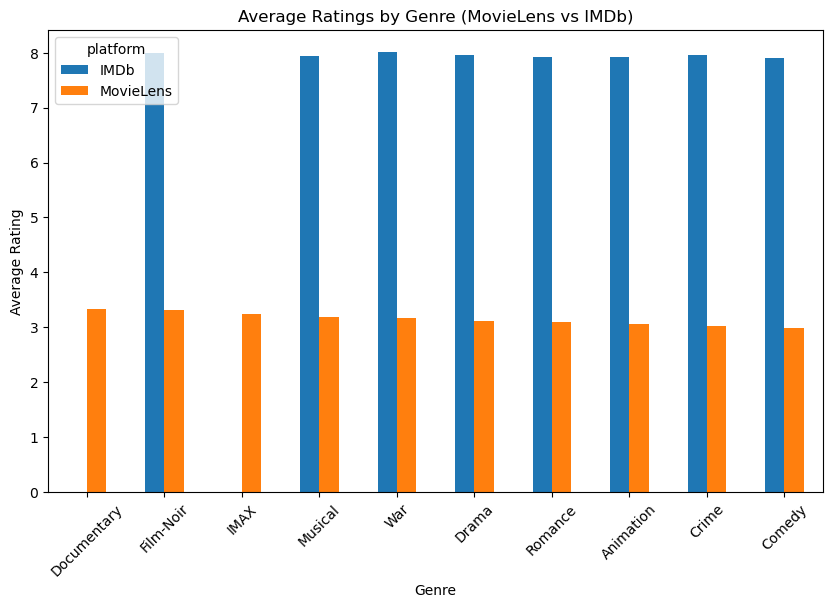

In [114]:
import matplotlib.pyplot as plt

ratings_pivot.sort_values(by='MovieLens', ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Ratings by Genre (MovieLens vs IMDb)")
plt.ylabel("Average Rating")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.show()

## Ratings Analysis Results

The analysis of average ratings by genre reveals clear patterns across MovieLens and IMDb. In the MovieLens dataset, the highest-rated genres include Documentary, Film-Noir, and IMAX, with average ratings slightly above 3.2. Other strong-performing genres such as Musical, War, and Drama also show relatively high user ratings, indicating consistent audience appreciation across these categories.

In contrast, IMDb ratings are significantly higher overall, with top genres such as War, Western, and Film-Noir receiving average ratings around 8.0. Additional genres including Sci-Fi, Mystery, Drama, and Crime also rank highly, reflecting IMDb’s focus on critically acclaimed and highly rated films.

When comparing the two platforms, both MovieLens and IMDb show agreement on certain high-quality genres such as Film-Noir, Drama, and Crime. However, IMDb ratings are consistently higher and more tightly clustered, while MovieLens ratings display greater variation due to being based on a broader range of user-generated reviews.

Overall, these results suggest that while both platforms recognize similar genres as high-quality, IMDb emphasizes critically acclaimed content, whereas MovieLens captures a wider spectrum of audience preferences.

In [115]:
## How has content production changed over time across MovieLens, Netflix, and IMDb?

In [116]:
print(movies_clean[['year_clean']].head())
print(netflix_clean[['year_clean']].head())
print(imdb_clean[['year_clean']].head())

   year_clean
0      1995.0
1      1995.0
2      1995.0
3      1995.0
4      1995.0
   year_clean
0        2020
1        2021
2        2021
3        2021
4        2021
   year_clean
0      1994.0
1      1972.0
2      2008.0
3      1974.0
4      1957.0


In [117]:
## Just confirming all datasets have years

In [118]:
movielens_year_counts = movies_clean['year_clean'].value_counts().reset_index()
movielens_year_counts.columns = ['year', 'count']
movielens_year_counts['platform'] = 'MovieLens'

print(movielens_year_counts.head())

     year  count   platform
0  2017.0   3269  MovieLens
1  2018.0   3180  MovieLens
2  2016.0   3167  MovieLens
3  2019.0   3084  MovieLens
4  2015.0   3080  MovieLens


In [119]:
## Count titles per year movielens

In [120]:
netflix_year_counts = netflix_clean['year_clean'].value_counts().reset_index()
netflix_year_counts.columns = ['year', 'count']
netflix_year_counts['platform'] = 'Netflix'

print(netflix_year_counts.head())

   year  count platform
0  2018   1147  Netflix
1  2017   1032  Netflix
2  2019   1030  Netflix
3  2020    953  Netflix
4  2016    902  Netflix


In [121]:
## Count titles per year netflix

In [122]:
imdb_year_counts = imdb_clean['year_clean'].value_counts().reset_index()
imdb_year_counts.columns = ['year', 'count']
imdb_year_counts['platform'] = 'IMDb'

print(imdb_year_counts.head())

     year  count platform
0  2014.0     32     IMDb
1  2004.0     31     IMDb
2  2009.0     29     IMDb
3  2013.0     28     IMDb
4  2016.0     28     IMDb


In [123]:
## Count titles per year Imdb

In [124]:
all_years = pd.concat([
    movielens_year_counts,
    netflix_year_counts,
    imdb_year_counts
])

print(all_years.head())

     year  count   platform
0  2017.0   3269  MovieLens
1  2018.0   3180  MovieLens
2  2016.0   3167  MovieLens
3  2019.0   3084  MovieLens
4  2015.0   3080  MovieLens


In [125]:
## Combine data sets

In [126]:
all_years = all_years.dropna(subset=['year'])
all_years = all_years[all_years['year'] > 1900]
all_years['year'] = all_years['year'].astype(int)

print(all_years.head())

   year  count   platform
0  2017   3269  MovieLens
1  2018   3180  MovieLens
2  2016   3167  MovieLens
3  2019   3084  MovieLens
4  2015   3080  MovieLens


In [127]:
## Clean values

In [128]:
year_pivot = all_years.pivot_table(
    index='year',
    columns='platform',
    values='count',
    fill_value=0
)

print(year_pivot.head())

platform  IMDb  MovieLens  Netflix
year                              
1901         0         45        0
1902         0         20        0
1903         0         32        0
1904         0         17        0
1905         0         19        0


In [129]:
## create pivot 

In [130]:
year_pivot = year_pivot.sort_index()

In [131]:
## sort by year

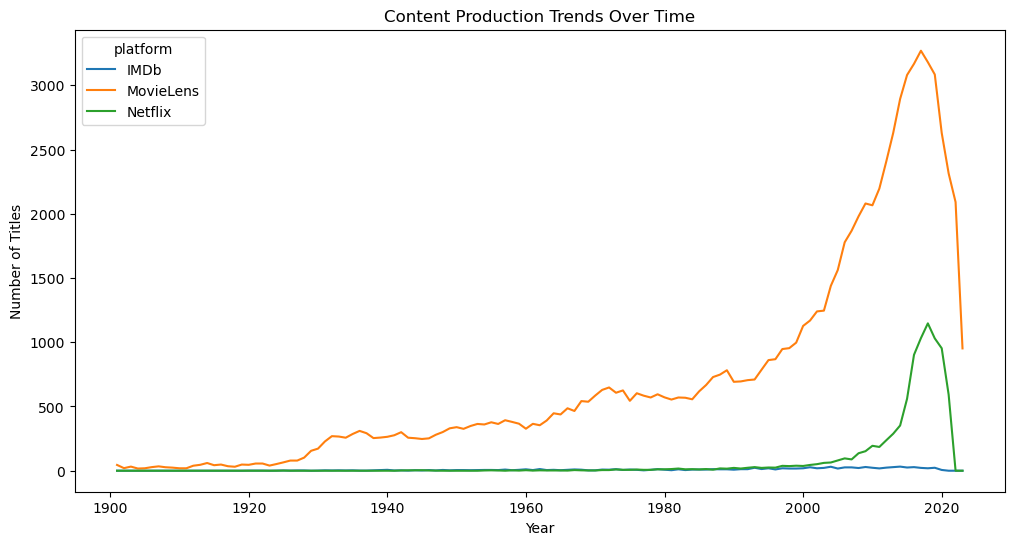

In [132]:
year_pivot.plot(figsize=(12,6))

plt.title("Content Production Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

## Release Trends Analysis Results

The analysis of content production trends over time reveals clear differences across MovieLens, Netflix, and IMDb. MovieLens shows a steady increase in the number of titles over time, with significant growth beginning in the late 20th century and peaking in recent years. This reflects the expansion of film production and the broad coverage of the MovieLens dataset, which includes a wide range of movies across many decades.

Netflix displays a sharp rise in content starting in the 2000s, with a rapid increase leading up to its peak around the late 2010s. This trend highlights the growth of streaming platforms and Netflix’s focus on expanding its modern content library. The sudden drop after the peak likely reflects limitations or cutoffs in the dataset rather than an actual decline in production.

IMDb, in contrast, shows relatively lower counts over time, indicating a more curated dataset focused on highly rated or notable films rather than overall volume. While it includes content from earlier decades, its growth is more gradual and less pronounced compared to MovieLens and Netflix.

Overall, these trends illustrate the evolution of the entertainment industry, from traditional film production represented by MovieLens and IMDb to the rapid expansion of digital streaming platforms like Netflix in recent years.